Connected to warehouse
Loaded 1,001 purchases from 905 unique shoppers
Reference date for recency: 2025-12-31 17:22:30

RFM summary:
       recency_days  frequency  monetary
count        905.00     905.00    905.00
mean         174.98       1.11    282.18
std          103.36       0.33    170.97
min            1.00       1.00     10.04
25%           86.00       1.00    132.12
50%          174.00       1.00    274.31
75%          258.00       1.00    410.14
max          364.00       3.00    941.07

Segment counts:
customer_segment
Loyal Customers    173
Champions          166
Lost               155
Needs Attention    153
New Customers      135
At Risk            123
Name: count, dtype: int64

Segment summary:
                  shopper_count  avg_recency  avg_frequency  total_revenue  \
customer_segment                                                             
Champions                   166        65.43           1.39       56712.08   
Loyal Customers             173       135.02    

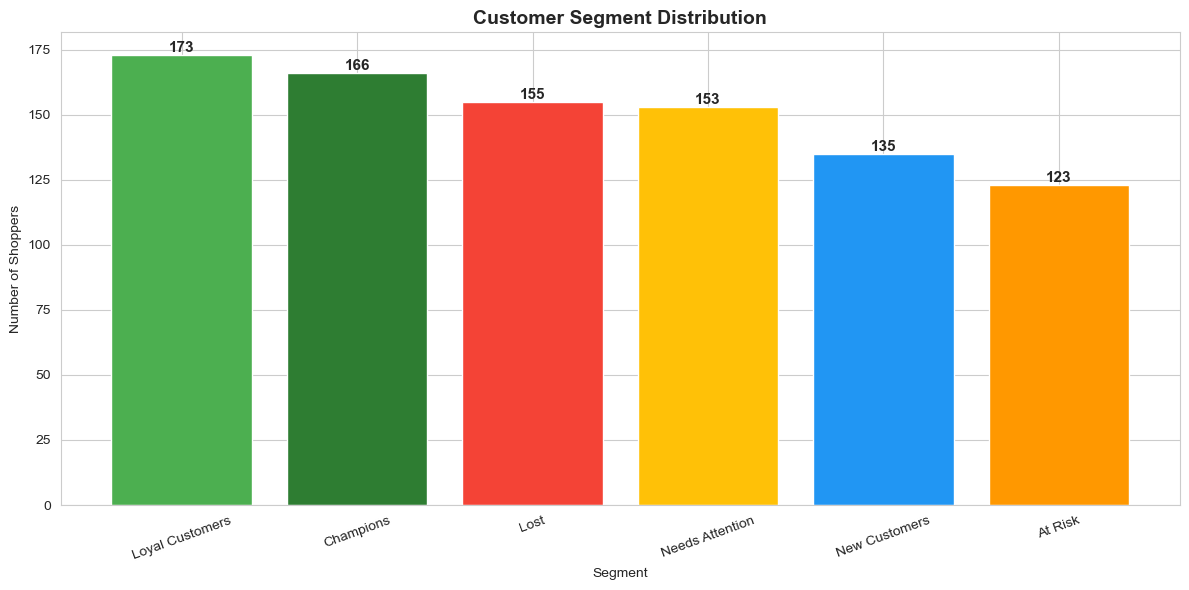

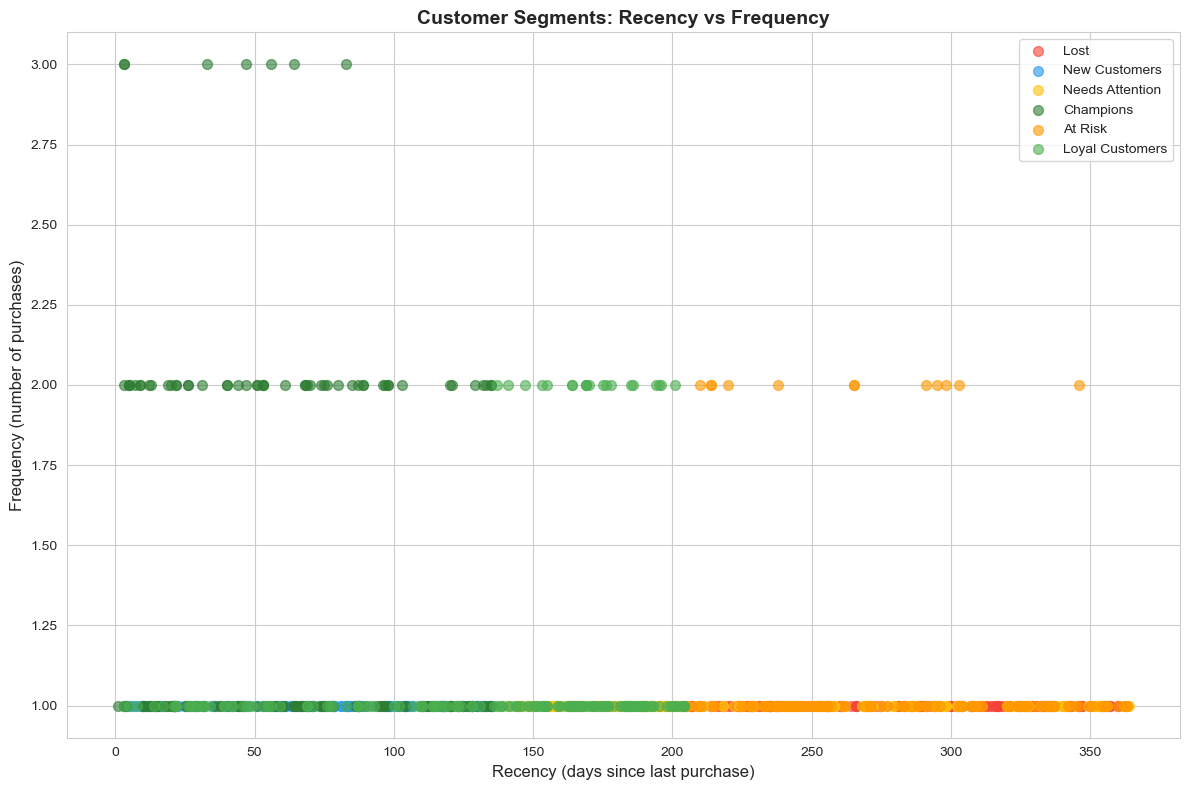

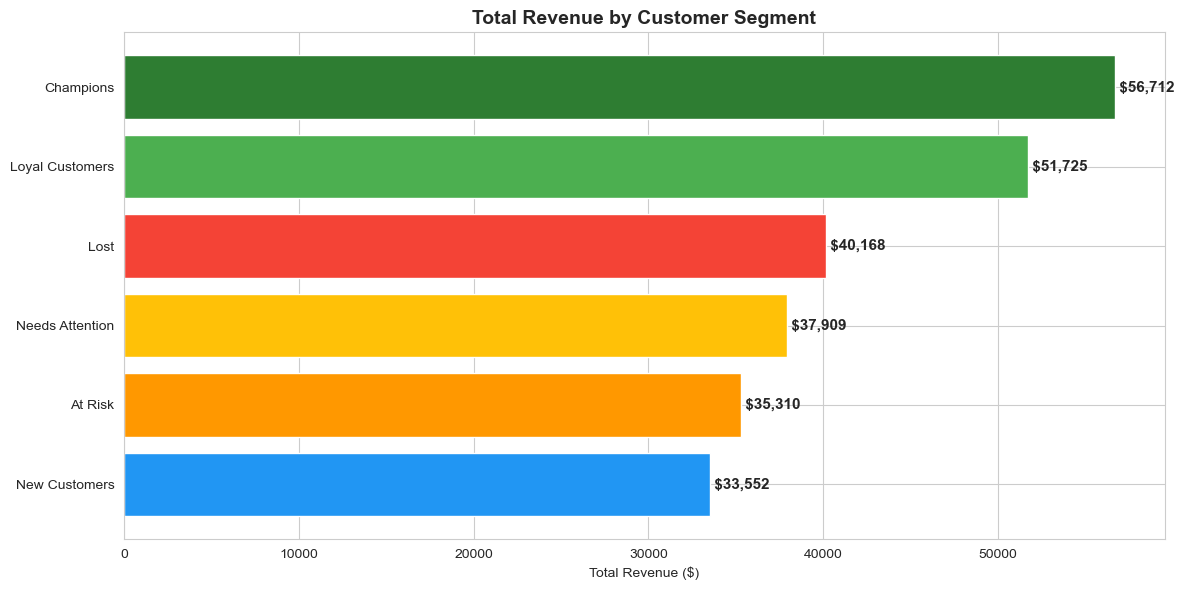


RFM results saved to data/processed/
Day 9 complete!


In [1]:
# Day 9: RFM Customer Segmentation (Recency, Frequency, Monetary)
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from datetime import datetime
import os
from dotenv import load_dotenv

load_dotenv('../.env')
warehouse_connection = create_engine(os.getenv('DATABASE_URL'))
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print("Connected to warehouse")

# ===== LOAD PURCHASE DATA FROM WAREHOUSE =====
purchase_query = """
SELECT 
    user_id AS shopper_id,
    timestamp AS purchase_time,
    amount AS spend
FROM fact_events
WHERE event_type = 'purchase'
  AND amount IS NOT NULL
ORDER BY user_id, timestamp;
"""
purchases = pd.read_sql(purchase_query, warehouse_connection)
purchases['purchase_time'] = pd.to_datetime(purchases['purchase_time'])
print(f"Loaded {len(purchases):,} purchases from {purchases['shopper_id'].nunique():,} unique shoppers")

# ===== CALCULATE RFM METRICS FOR EACH SHOPPER =====
analysis_date = purchases['purchase_time'].max() + pd.Timedelta(days=1)
print(f"Reference date for recency: {analysis_date}")

shopper_rfm = purchases.groupby('shopper_id').agg(
    last_purchase=('purchase_time', 'max'),
    order_count=('purchase_time', 'count'),
    total_revenue=('spend', 'sum')
).reset_index()

# Recency = days since last purchase (lower = better)
shopper_rfm['days_since_last_purchase'] = (analysis_date - shopper_rfm['last_purchase']).dt.days

# Rename for clarity
shopper_rfm = shopper_rfm.rename(columns={
    'days_since_last_purchase': 'recency_days',
    'order_count': 'frequency',
    'total_revenue': 'monetary'
})

print(f"\nRFM summary:")
print(shopper_rfm[['recency_days', 'frequency', 'monetary']].describe().round(2))

# ===== SCORE EACH SHOPPER 1-5 ON R, F, M =====
# For Recency: LOWER days = BETTER, so we flip the order (5 = most recent)
shopper_rfm['recency_score'] = pd.qcut(
    shopper_rfm['recency_days'], 
    q=5, 
    labels=[5, 4, 3, 2, 1], 
    duplicates='drop'
).astype(int)

# For Frequency and Monetary: HIGHER = BETTER (5 = best)
shopper_rfm['frequency_score'] = pd.qcut(
    shopper_rfm['frequency'].rank(method='first'), 
    q=5, 
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
).astype(int)

shopper_rfm['monetary_score'] = pd.qcut(
    shopper_rfm['monetary'], 
    q=5, 
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
).astype(int)

# Combined RFM score
shopper_rfm['rfm_score'] = (
    shopper_rfm['recency_score'].astype(str) + 
    shopper_rfm['frequency_score'].astype(str) + 
    shopper_rfm['monetary_score'].astype(str)
)

# ===== ASSIGN SEGMENTS BASED ON R AND F SCORES =====
def assign_segment(row):
    r = row['recency_score']
    f = row['frequency_score']
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

shopper_rfm['customer_segment'] = shopper_rfm.apply(assign_segment, axis=1)

print(f"\nSegment counts:")
segment_counts = shopper_rfm['customer_segment'].value_counts()
print(segment_counts)

# ===== CALCULATE SEGMENT VALUE =====
segment_summary = shopper_rfm.groupby('customer_segment').agg(
    shopper_count=('shopper_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    total_revenue=('monetary', 'sum'),
    avg_revenue_per_shopper=('monetary', 'mean')
).round(2).sort_values('total_revenue', ascending=False)

print(f"\nSegment summary:")
print(segment_summary)

# ===== VISUALIZATION 1: SEGMENT DISTRIBUTION =====
segment_colors = {
    'Champions': '#2E7D32',
    'Loyal Customers': '#4CAF50',
    'New Customers': '#2196F3',
    'Needs Attention': '#FFC107',
    'At Risk': '#FF9800',
    'Lost': '#F44336'
}

fig, ax = plt.subplots(figsize=(12, 6))
colors_list = [segment_colors.get(seg, '#999999') for seg in segment_counts.index]
bars = ax.bar(segment_counts.index, segment_counts.values, color=colors_list)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Shoppers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ===== VISUALIZATION 2: RECENCY vs FREQUENCY SCATTER =====
fig, ax = plt.subplots(figsize=(12, 8))
for segment in shopper_rfm['customer_segment'].unique():
    mask = shopper_rfm['customer_segment'] == segment
    ax.scatter(
        shopper_rfm.loc[mask, 'recency_days'],
        shopper_rfm.loc[mask, 'frequency'],
        label=segment,
        color=segment_colors.get(segment, '#999999'),
        alpha=0.6,
        s=50
    )
ax.set_xlabel('Recency (days since last purchase)', fontsize=12)
ax.set_ylabel('Frequency (number of purchases)', fontsize=12)
ax.set_title('Customer Segments: Recency vs Frequency', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ===== VISUALIZATION 3: REVENUE BY SEGMENT =====
fig, ax = plt.subplots(figsize=(12, 6))
revenue_by_segment = segment_summary['total_revenue'].sort_values(ascending=True)
colors_rev = [segment_colors.get(seg, '#999999') for seg in revenue_by_segment.index]
bars = ax.barh(revenue_by_segment.index, revenue_by_segment.values, color=colors_rev)
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' ${width:,.0f}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

# ===== SAVE RESULTS =====
os.makedirs('../data/processed', exist_ok=True)
shopper_rfm.to_csv('../data/processed/rfm_segmentation.csv', index=False)
segment_summary.to_csv('../data/processed/segment_summary.csv')

print("\nRFM results saved to data/processed/")
print("Day 9 complete!")